1. Introducción: **"El Expediente"**

*   ***Mi Misión (Markdown):*** Presentando el "Expediente: Crímenes en Chicago".
*   ***Dataset:*** Reportes de crímenes de la Policía de Chicago.
*   ***Fuente:*** Kaggle.
*   ***Preguntas Guía:***

      *   ¿Cuál es el modus operandi (tipo de crimen) más común en Chicago y cómo cambia su patrón según la hora del día y el día de la semana?

      *   ¿Dónde se ubican los 'puntos calientes' (hotspots) de los crímenes más graves (ej. Asalto, Robo) y en qué meses del año se intensifican?







In [ ]:
import kagglehub

path = kagglehub.dataset_download("currie32/crimes-in-chicago")

print("Path to dataset files:", path)

import pandas as pd
import numpy as np

# otros archivos disponibles son: Chicago_Crimes_2012_to_2017.csv y Chicago_Crimes_2001_to_2007.csv
df = pd.read_csv(f'{path}/Chicago_Crimes_2008_to_2011.csv', low_memory=False, on_bad_lines='skip')
#trabajaré con el punto intermedio, ni muy vintage pero tampoco muy actual

# 1. Vistazo a las primeras 5 pistas (Head)
print(" PISTAS SUPERIORES")
print("Inspeccionando las primeras 5 filas del expediente")
print(df.head())

100%|██████████| 467M/467M [00:04<00:00, 101MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/currie32/crimes-in-chicago/versions/1
 PISTAS SUPERIORES
Inspeccionando las primeras 5 filas del expediente
   Unnamed: 0    ID Case Number                    Date                Block  \
0         388  4785    HP610824  10/07/2008 12:39:00 PM      000XX E 75TH ST   
1         835  4786    HP616595  10/09/2008 03:30:00 AM      048XX W POLK ST   
2        1334  4787    HP616904  10/09/2008 08:35:00 AM      030XX W MANN DR   
3        1907  4788    HP618616  10/10/2008 02:33:00 AM  052XX W CHICAGO AVE   
4        2436  4789    HP619020  10/10/2008 12:50:00 PM    026XX S HOMAN AVE   

   IUCR Primary Type          Description Location Description  Arrest  ...  \
0  0110     HOMICIDE  FIRST DEGREE MURDER                ALLEY    True  ...   
1  0110     HOMICIDE  FIRST DEGREE MURDER               STREET    True  ...   
2  0110     HOMICIDE  FIRST DEGREE MURDER        PARK PROPERTY   False  ...   
3  0110     HOMICIDE  FIRST DEGREE MURDE

In [ ]:
# 2. Informe de la Escena del Crimen (Info)
print("\n INFORME DE LA ESCENA")
print("Revisando la integridad del expediente (nulos y tipos de datos)")
df.info() # Revisar si hay testigos "mudos" (valores nulos)


 INFORME DE LA ESCENA
Revisando la integridad del expediente (nulos y tipos de datos)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2688710 entries, 0 to 2688709
Data columns (total 23 columns):
 #   Column                Dtype  
---  ------                -----  
 0   Unnamed: 0            int64  
 1   ID                    int64  
 2   Case Number           object 
 3   Date                  object 
 4   Block                 object 
 5   IUCR                  object 
 6   Primary Type          object 
 7   Description           object 
 8   Location Description  object 
 9   Arrest                bool   
 10  Domestic              bool   
 11  Beat                  int64  
 12  District              float64
 13  Ward                  float64
 14  Community Area        float64
 15  FBI Code              object 
 16  X Coordinate          float64
 17  Y Coordinate          float64
 18  Year                  int64  
 19  Updated On            object 
 20  Latitude              flo

In [ ]:
# 3. Interrogatorio: Detectar "Testimonios Incompletos" (Nulos)
print("Contando pistas faltantes (NaN) por columna")

pistas_faltantes = df.isnull().sum()
print(pistas_faltantes)

Contando pistas faltantes (NaN) por columna
Unnamed: 0                  0
ID                          0
Case Number                 6
Date                        0
Block                       0
IUCR                        0
Primary Type                0
Description                 0
Location Description      291
Arrest                      0
Domestic                    0
Beat                        0
District                   83
Ward                       63
Community Area           1455
FBI Code                    0
X Coordinate            28645
Y Coordinate            28645
Year                        0
Updated On                  0
Latitude                28645
Longitude               28645
Location                28645
dtype: int64


In [ ]:
#  4. Interrogatorio: Detectar "Reportes Duplicados"
print("\n Buscando reportes duplicados...")

duplicados = df.duplicated().sum()
print(f"Cantidad de reportes idénticos encontrados: {duplicados}")


 Buscando reportes duplicados...
Cantidad de reportes idénticos encontrados: 1147495


In [ ]:
# 5. Limpieza de Datos: Eliminando Pistas Faltantes e Irrelevantes

print(f"Reportes originales en el expediente: {len(df)}")


Reportes originales en el expediente: 2688710


In [ ]:
# 5A. Elimino Pistas Faltantes (Nulos)
# me voy a enfocar en las columnas clave para los "hotspots".

df.dropna(subset=['Latitude', 'Longitude', 'District'], inplace=True)
print(f"Reportes restantes después de eliminar nulos: {len(df)}")


Reportes restantes después de eliminar nulos: 2659982


In [ ]:
# 5B. Elimino Pistas Irrelevantes
# a mi investigación (Modus Operandi y Hotspots).

columnas_irrelevantes = ['Unnamed: 0', 'ID', 'Case Number', 'IUCR',
                         'Beat', 'Ward', 'Community Area', 'FBI Code',
                         'X Coordinate', 'Y Coordinate', 'Updated On', 'Location']

df.drop(columns=columnas_irrelevantes, inplace=True)
print("Pistas irrelevantes eliminadas de la mesa de pruebas.")

Pistas irrelevantes eliminadas de la mesa de pruebas.


In [ ]:
# 5C. Elimino Reportes Duplicados

df.drop_duplicates(inplace=True)
print(f"Reportes restantes después de eliminar duplicados: {len(df)}")


print("\n INFORME POST-LIMPIEZA")
print("El expediente ahora está limpio y listo para el análisis.")
df.info()

Reportes restantes después de eliminar duplicados: 1522839

 INFORME POST-LIMPIEZA
El expediente ahora está limpio y listo para el análisis.
<class 'pandas.core.frame.DataFrame'>
Index: 1522839 entries, 0 to 2688709
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Date                  1522839 non-null  object 
 1   Block                 1522839 non-null  object 
 2   Primary Type          1522839 non-null  object 
 3   Description           1522839 non-null  object 
 4   Location Description  1522612 non-null  object 
 5   Arrest                1522839 non-null  bool   
 6   Domestic              1522839 non-null  bool   
 7   District              1522839 non-null  float64
 8   Year                  1522839 non-null  int64  
 9   Latitude              1522839 non-null  float64
 10  Longitude             1522839 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(5)
memory usage:

In [ ]:
# 6. Transformación: "Descifrando el Código" (Fechas)
print(" Transformando la pista 'Date' (object) ")

# La pista "Date" es un impostor (es de tipo object). La interrogaré usando
# .str.split().

# Pista original: "10/07/2008 12:39:00 PM" es todo texto

# 6A. Dividimos la pista por el espacio (' ')
# Esto la separa en 3 partes: ['10/07/2008', '12:39:00', 'PM']
partes_fecha_hora = df['Date'].str.split(' ')

# 6B. Creamos la columna 'Period' (AM/PM)
# Esta es la parte en el índice 2
df['Period'] = partes_fecha_hora.str[2]
print("Pista 'Period' (AM/PM) extraída.")

# 6C. Extraemos la hora ('12:39:00')
# Esta es la parte en el índice 1
hora_completa = partes_fecha_hora.str[1]

# 6D. Dividimos la hora por los dos puntos (':')
# Esto la separa en 3 partes: ['12', '39', '00']
partes_hora = hora_completa.str.split(':')

# 6E. Creamos la columna 'Hour'
# Esta es la parte en el índice 0
df['Hour'] = partes_hora.str[0]
print("Pista 'Hour' (Hora) extraída.")

# 6F. Extraemos la fecha ('10/07/2008')
# Esta es la parte en el índice 0
fecha_completa = partes_fecha_hora.str[0]

# 6G. Dividimos la fecha por la barra ('/')
# Esto la separa en 3 partes: ['10', '07', '2008']
partes_fecha = fecha_completa.str.split('/')

# 6H. Creamos la columna 'Month'
# Esta es la parte en el índice 0
df['Month'] = partes_fecha.str[0]
print("Pista 'Month' (Mes) extraída.")




 Transformando la pista 'Date' (object) 
Pista 'Period' (AM/PM) extraída.
Pista 'Hour' (Hora) extraída.
Pista 'Month' (Mes) extraída.


In [ ]:
# 7. Verificación de las nuevas pistas
print("\n  Verificando las nuevas pistas...")
df.head()


  Verificando las nuevas pistas...


,Date,Block,Primary Type,Description,Location Description,Arrest,Domestic,District,Year,Latitude,Longitude,Period,Hour,Month
0,10/07/2008 12:39:00 PM,000XX E 75TH ST,HOMICIDE,FIRST DEGREE MURDER,ALLEY,True,False,3.0,2008,41.758276,-87.622451,PM,12,10
1,10/09/2008 03:30:00 AM,048XX W POLK ST,HOMICIDE,FIRST DEGREE MURDER,STREET,True,False,15.0,2008,41.870252,-87.746069,AM,03,10
2,10/09/2008 08:35:00 AM,030XX W MANN DR,HOMICIDE,FIRST DEGREE MURDER,PARK PROPERTY,False,False,8.0,2008,41.770990,-87.698901,AM,08,10
3,10/10/2008 02:33:00 AM,052XX W CHICAGO AVE,HOMICIDE,FIRST DEGREE MURDER,RESTAURANT,False,False,15.0,2008,41.894917,-87.757358,AM,02,10
4,10/10/2008 12:50:00 PM,026XX S HOMAN AVE,HOMICIDE,FIRST DEGREE MURDER,GARAGE,False,True,10.0,2008,41.843826,-87.709893,PM,12,10


In [ ]:
# 8. Limpieza Final: Eliminando la Pista Falsa "Date"
print(" Eliminando la pista 'Date' (object) original")
df.drop(columns=['Date'], inplace=True)

print("Pista 'Date' original eliminada.")
df.info() # Un último vistazo para confirmar que todo está limpio

 Eliminando la pista 'Date' (object) original
Pista 'Date' original eliminada.
<class 'pandas.core.frame.DataFrame'>
Index: 1522839 entries, 0 to 2688709
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   Block                 1522839 non-null  object 
 1   Primary Type          1522839 non-null  object 
 2   Description           1522839 non-null  object 
 3   Location Description  1522612 non-null  object 
 4   Arrest                1522839 non-null  bool   
 5   Domestic              1522839 non-null  bool   
 6   District              1522839 non-null  float64
 7   Year                  1522839 non-null  int64  
 8   Latitude              1522839 non-null  float64
 9   Longitude             1522839 non-null  float64
 10  Period                1522839 non-null  object 
 11  Hour                  1522839 non-null  object 
 12  Month                 1522839 non-null  object 
dtypes: bool(2), f

In [ ]:
# 9. Visualización: ¿Cuál es el "Modus Operandi"?
print(" Identificando el Modus Operandi (Primary Type)")

# Uso .value_counts() para contar los crímenes
# y .head(10) para ver el Top 10
top_10_crimes = df['Primary Type'].value_counts().head(10)

print("--- Top 10 Crímenes Más Comunes ---")
print(top_10_crimes)

 Identificando el Modus Operandi (Primary Type)
--- Top 10 Crímenes Más Comunes ---
Primary Type
THEFT                  316829
BATTERY                268677
CRIMINAL DAMAGE        176798
NARCOTICS              168547
BURGLARY               105151
OTHER OFFENSE           93331
ASSAULT                 89707
MOTOR VEHICLE THEFT     72187
ROBBERY                 60617
DECEPTIVE PRACTICE      51579
Name: count, dtype: int64


***¿Cuál es el "Modus Operandi"?*** = *THEFT*  (Robos) 316.829 registrados





Creando gráfico de barras para el 'Modus Operandi'


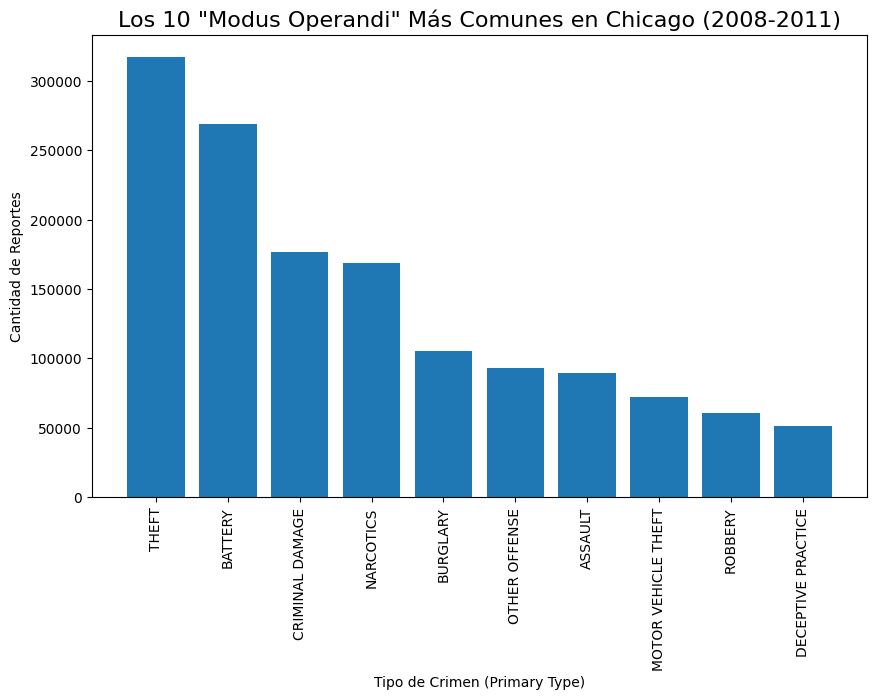

In [ ]:
# 10. Visualización: Gráfico del Modus Operandi
import matplotlib.pyplot as plt

print("Creando gráfico de barras para el 'Modus Operandi'")

# Creo la figura. Un tamaño más grande que ayude a leer
plt.figure(figsize=(10, 6))

# Uso plt.bar() como se menciona en el Data Challenge.
# .index son los nombres de los crímenes (eje X)
# .values son las cantidades (eje Y)
plt.bar(top_10_crimes.index, top_10_crimes.values)

# Añadí las "etiquetas" que pide el Inspector Lestrade (el Data Challenge)
plt.title('Los 10 "Modus Operandi" Más Comunes en Chicago (2008-2011)', fontsize=16)
plt.ylabel('Cantidad de Reportes')
plt.xlabel('Tipo de Crimen (Primary Type)')

# Esta línea es para que los nombres de los crímenes no se superpongan
plt.xticks(rotation=90)

# Guardo la imagen para la presentación PPT
plt.savefig('top_10_crimes_modus_operandi.png', bbox_inches='tight')

# Muestro el gráfico
plt.show()

In [ ]:
# 11. Visualización: Identificando "Hotspots" por Distrito
print(" Identificando los 10 Distritos con más reportes")

# Cuento los reportes por distrito y tomo el Top 10
top_10_distritos = df['District'].value_counts().head(10)

print("--- Top 10 Distritos con más Crímenes ---")
print(top_10_distritos)


 Identificando los 10 Distritos con más reportes
--- Top 10 Distritos con más Crímenes ---
District
8.0     110104
7.0      93712
25.0     92835
11.0     91482
6.0      90237
4.0      89671
3.0      79352
9.0      76508
12.0     71828
5.0      68416
Name: count, dtype: int64



 Creando gráfico de barras para 'Hotspots por Distrito' 


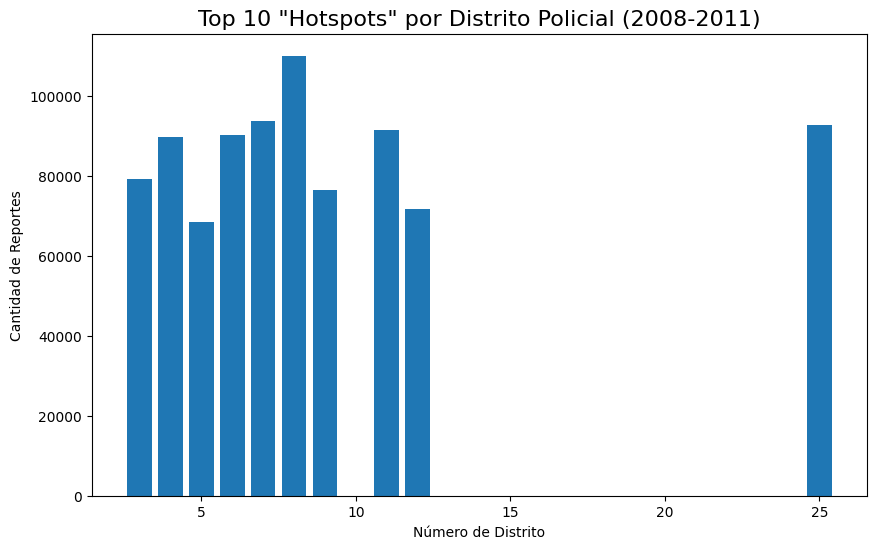

In [ ]:
#  12. Visualización: Gráfico de Barras de Distritos
print("\n Creando gráfico de barras para 'Hotspots por Distrito' ")

plt.figure(figsize=(10, 6))

# Uso plt.bar()
plt.bar(top_10_distritos.index, top_10_distritos.values)

# Añado las "etiquetas"
plt.title('Top 10 "Hotspots" por Distrito Policial (2008-2011)', fontsize=16)
plt.ylabel('Cantidad de Reportes')
plt.xlabel('Número de Distrito')

# Guardo la imagen
plt.savefig('top_10_distritos_hotspots.png', bbox_inches='tight')

# Muestro el gráfico
plt.show()

Tomando una muestra más grande para el mapa (200,000 crímenes)... 
Creando el 'Mapa de Alfileres'


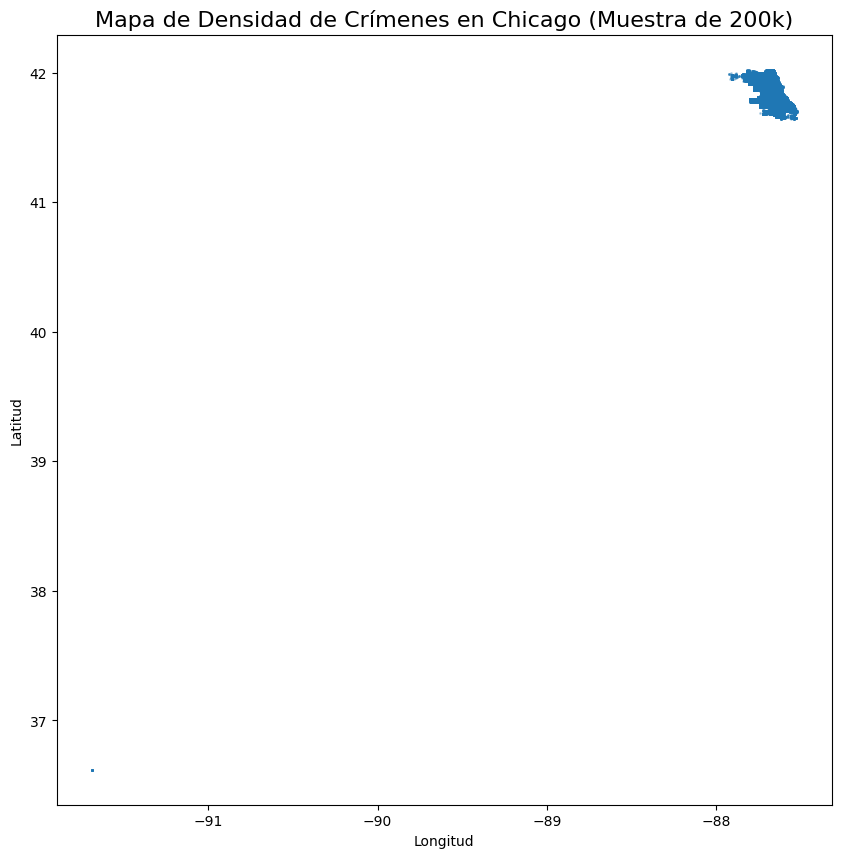

In [ ]:
# 13. Visualización: El "Mapa de Alfileres" (mi toque personal)
print("Tomando una muestra más grande para el mapa (200,000 crímenes)... ")

df_sample_ajustado = df.sample(200000)

print("Creando el 'Mapa de Alfileres'")

plt.figure(figsize=(10, 10))

# Uso plt.scatter()
# alpha=0.3 hace los puntos más visibles
# s=1 mantiene los puntos pequeños para que no se "empasten" demasiado
plt.scatter(df_sample_ajustado['Longitude'], df_sample_ajustado['Latitude'], alpha=0.3, s=1)

# Añado las "etiquetas"
plt.title('Mapa de Densidad de Crímenes en Chicago (Muestra de 200k)', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')

# Guardo la imagen
plt.savefig('mapa_densidad_crimenes_ajustado.png', bbox_inches='tight')

# Muestro el gráfico
plt.show()

***Análisis del Problema Real: La Pista Falsa***


*   Lo que está sucediendo es que, aunque limpié los NaN (nulos), deben existir algunos reportes con coordenadas erróneas.

*   Imaginando un poco, estoy investigando un caso en Chicago, pero en el expediente hay 2 o 3 pistas que dicen "Latitud 0, Longitud 0" (en medio del océano) o una coordenada de otra ciudad.


*   Entonces Matplotlib, en su intento de mostrar todas las pistas, aleja el zoom del mapa para incluir ese punto erróneo en el océano. Esto hace que Chicago, donde están el 99.9% de las pistas, se vea como una mancha en la parte superior derecha del gráfico.

*   Debo interrogar a las columnas Latitude y Longitude para encontrar los límites de la "jurisdicción" correcta.






Prosigo entonces con el siguiente paso: **Descubrir al "Mentiroso"**



In [ ]:
# 14. Interrogatorio: Buscando "Pistas Falsas" (Outliers) en Coordenadas
print("Revisando los límites de nuestra jurisdicción (Coordenadas)")

# Uso .describe() para ver los valores min y max.
# Esto revelará a los "mentirosos" (outliers).
print(df[['Latitude', 'Longitude']].describe())

Revisando los límites de nuestra jurisdicción (Coordenadas)
           Latitude     Longitude
count  1.522839e+06  1.522839e+06
mean   4.184042e+01 -8.767249e+01
std    9.669646e-02  6.771364e-02
min    3.661945e+01 -9.168657e+01
25%    4.176723e+01 -8.771461e+01
50%    4.185254e+01 -8.766699e+01
75%    4.190738e+01 -8.762880e+01
max    4.202255e+01 -8.752453e+01


In [ ]:
# 15. Limpieza: Delimitando la "Jurisdicción" (Filtrado de Outliers)
print(" Delimitando la escena del crimen a Chicago... ")

# Filtro para quedarme solo con coordenadas lógicas de Chicago.
# (Estos valores 41-43 y -87 a -88 son rangos seguros para Chicago)
df_chicago = df[ (df['Latitude'] > 41.0) & (df['Latitude'] < 43.0) &
                 (df['Longitude'] > -88.0) & (df['Longitude'] < -87.0) ]

print(f"Reportes originales: {len(df)}")
print(f"Reportes DENTRO de Chicago: {len(df_chicago)}")


 Delimitando la escena del crimen a Chicago... 
Reportes originales: 1522839
Reportes DENTRO de Chicago: 1522738


Creando el 'Mapa de Alfileres'


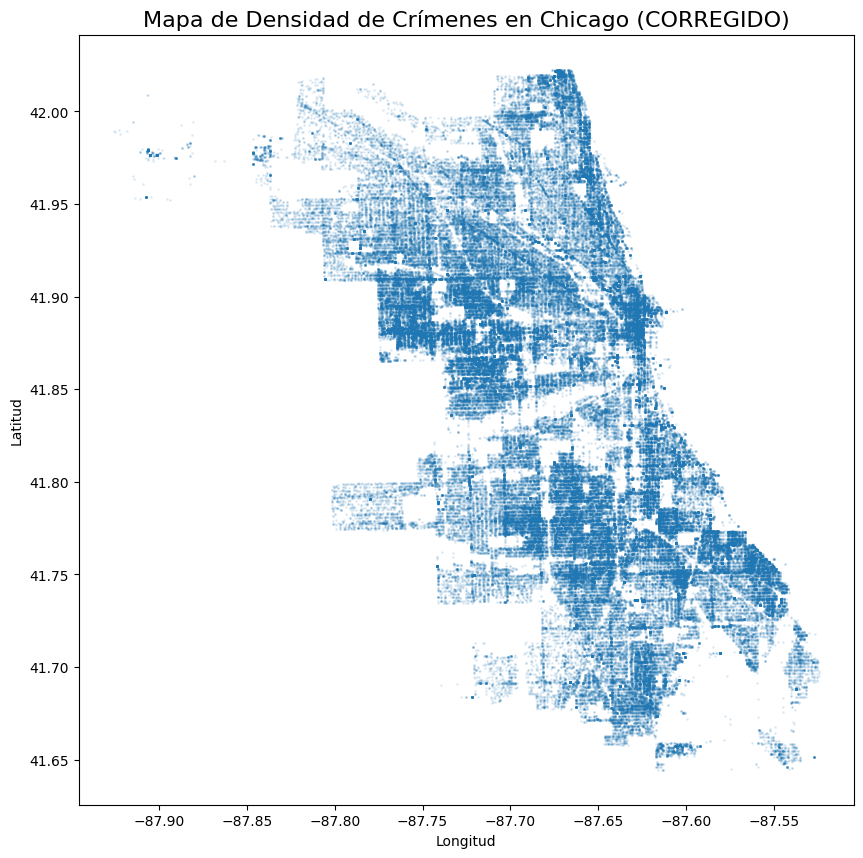

In [ ]:
# 16. Visualización: El "Mapa de Alfileres"
print("Creando el 'Mapa de Alfileres'")

# Ahora uso una muestra del DF limpio 'df_chicago'
# Tomo 200,000 muestras para que sea denso pero no imposible de procesar para Google Colab
df_sample_corregido = df_chicago.sample(200000)

plt.figure(figsize=(10, 10))

# Ajusto el alpha de nuevo para buena visibilidad
plt.scatter(df_sample_corregido['Longitude'], df_sample_corregido['Latitude'], alpha=0.1, s=1)

# Añado las "etiquetas"
plt.title('Mapa de Densidad de Crímenes en Chicago (CORREGIDO)', fontsize=16)
plt.xlabel('Longitud')
plt.ylabel('Latitud')

# Guardo la imagen
plt.savefig('mapa_densidad_corregido.png', bbox_inches='tight')

plt.show()

***Resolviendo la Pregunta Completa: "Los Puntos Calientes"***

Esta pregunta tiene dos partes:



1.   El DÓNDE (¿Cuáles son los "puntos calientes" geográficos?)

2.   El CUÁNDO (¿En qué meses se intensifican?)


Identificando los 10 Distritos con más reportes
--- Top 10 Distritos con más Crímenes ---
District
8.0     110104
7.0      93712
25.0     92835
11.0     91482
6.0      90237
4.0      89671
3.0      79352
9.0      76508
12.0     71828
5.0      68416
Name: count, dtype: int64

 Creando gráfico de barras para 'Hotspots por Distrito' 


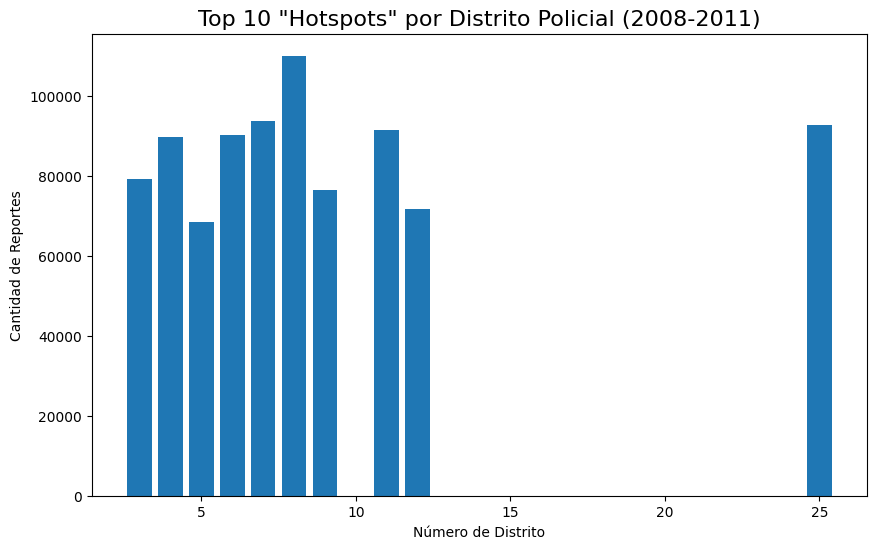

In [ ]:
#Hotspots "DONDE"

# 17. Visualización: Identificando "Hotspots" por Distrito
print("Identificando los 10 Distritos con más reportes" )

# Cuento los reportes por distrito y tomo el Top 10
top_10_distritos = df['District'].value_counts().head(10)

print("--- Top 10 Distritos con más Crímenes ---")
print(top_10_distritos)

# 18. Visualización: Gráfico de Barras de Distritos
print("\n Creando gráfico de barras para 'Hotspots por Distrito' ")

plt.figure(figsize=(10, 6))

# Uso plt.bar()
plt.bar(top_10_distritos.index, top_10_distritos.values)

# Añado las "etiquetas"
plt.title('Top 10 "Hotspots" por Distrito Policial (2008-2011)', fontsize=16)
plt.ylabel('Cantidad de Reportes')
plt.xlabel('Número de Distrito')

# Guardo la imagen
plt.savefig('top_10_distritos_hotspots.png', bbox_inches='tight')

# Muestro el gráfico
plt.show()

 Analizando en qué meses se intensifica el crimen 
--- Crímenes por Mes ---
Month
01    118225
02    102874
03    127368
04    127609
05    136968
06    135578
07    141240
08    141396
09    131734
10    131938
11    119382
12    108527
Name: count, dtype: int64

 Creando gráfico de barras para 'Crímenes por Mes'


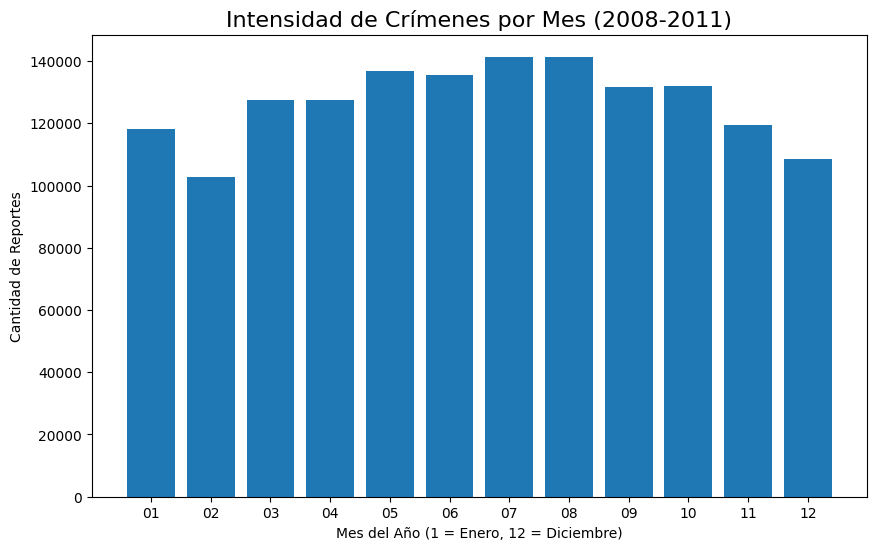

In [ ]:
#Hotspots CUANDO


# 19. Visualización: Análisis Temporal (Meses)
print(" Analizando en qué meses se intensifica el crimen ")

# Cuento los crímenes por mes
crimes_por_mes = df['Month'].value_counts()

# Importante: Ordeno los meses por el índice (de 1 a 12)
# Usando .sort_index() que es similar a .sort_values()
crimes_por_mes = crimes_por_mes.sort_index()

print("--- Crímenes por Mes ---")
print(crimes_por_mes)

# 20. Visualización: Gráfico de Barras de Meses
print("\n Creando gráfico de barras para 'Crímenes por Mes'")

plt.figure(figsize=(10, 6))

# Uso plt.bar()
plt.bar(crimes_por_mes.index, crimes_por_mes.values)

# Añado las "etiquetas"
plt.title('Intensidad de Crímenes por Mes (2008-2011)', fontsize=16)
plt.ylabel('Cantidad de Reportes')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.xticks(crimes_por_mes.index) # Me aseguro de que salgan todos los meses

# Guardo la imagen
plt.savefig('crimenes_por_mes.png', bbox_inches='tight')

# Muestro el gráfico
plt.show()